# Projeto de Otimização de Rotas de Vistorias Rodoviárias

Autor: Carlos Israel L Costa

### Importações, Download dos Dados e Setup

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, LineString

# DOWNLOAD DOS ARQUIVOS
!wget -O brs-pa-distances.csv https://raw.githubusercontent.com/lid-ufpa/genial/main/projeto-final/aco/brs-pa-distances.csv
!wget -O brs-pa-coordinates.pkl https://raw.githubusercontent.com/lid-ufpa/genial/main/projeto-final/aco/brs-pa-coordinates.pkl

# CONSTANTES GLOBAIS
BELEM_LAT, BELEM_LON = -1.4558, -48.5025 # Coordenadas de Belém
R_EARTH = 6371.0 # Raio da Terra em km

--2025-12-06 20:59:15--  https://raw.githubusercontent.com/lid-ufpa/genial/main/projeto-final/aco/brs-pa-distances.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2249 (2.2K) [text/plain]
Saving to: ‘brs-pa-distances.csv’

brs-pa-distances.cs 100%[===================>]   2.20K  --.-KB/s    in 0s      

2025-12-06 20:59:15 (26.1 MB/s) - ‘brs-pa-distances.csv’ saved [2249/2249]

--2025-12-06 20:59:15--  https://raw.githubusercontent.com/lid-ufpa/genial/main/projeto-final/aco/brs-pa-coordinates.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response..

### Carregamento, Pré-processamento, Matrizes Base, Função Objetivo

In [2]:
# Carregamento e Tratamento Inicial
df_coords = pd.read_pickle("brs-pa-coordinates.pkl")
df_distances_raw = pd.read_csv("brs-pa-distances.csv", index_col=0)
df_coords[['lon', 'lat']] = df_coords['coordinate'].apply(pd.Series)

# --- Função Haversine (Definida aqui por ser usada no pré-processamento) ---
def haversine_distance(lat1, lon1, lat2, lon2):
    # Lógica da Haversine (como definida na parte I)
    lat1_rad, lat2_rad = np.radians(lat1), np.radians(lat2)
    dlon, dlat = np.radians(lon2 - lon1), np.radians(lat2 - lat1)
    a = np.sin(dlat/2.0)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R_EARTH * c

# Cálculo das Métricas Base
df_coords['dist_belem'] = haversine_distance(BELEM_LAT, BELEM_LON, df_coords['lat'], df_coords['lon'])

# Mapeamentos e Índices
node_labels = df_distances_raw.index.tolist()
node_to_idx = {label: idx for idx, label in enumerate(node_labels)}
idx_to_node = {idx: label for label, idx in node_to_idx.items()}
DISTANCE_MATRIX = df_distances_raw.values
NUM_NODES = len(DISTANCE_MATRIX)

# Ponto Inicial (n1) e Distâncias de Belém
initial_node_belem_distance = df_coords['dist_belem'].min()
initial_node_id = df_coords.loc[df_coords['dist_belem'].idxmin(), 'identificador']
initial_node_idx = node_to_idx[initial_node_id]

# Matriz de Visibilidade (η)
VISIBILITY_MATRIX = np.zeros(DISTANCE_MATRIX.shape)
non_zero_mask = DISTANCE_MATRIX != 0
VISIBILITY_MATRIX[non_zero_mask] = 1.0 / DISTANCE_MATRIX[non_zero_mask]

# Feromônio Inicial (τ₀)
TAU_ZERO = 1.0 / (NUM_NODES * np.min(DISTANCE_MATRIX[DISTANCE_MATRIX > 0]))

print(f"✅ Ponto de Partida ({initial_node_id}) e Matrizes de Visibilidade prontos.")

✅ Ponto de Partida (BR-316) e Matrizes de Visibilidade prontos.


Define o mecanismo central de escolha da formiga. Refinando o df para melhor visualização do que vamos precisar:

In [3]:
def select_next_node(current_node_idx, visited_nodes, alpha, beta):
    """Calcula P_ij e seleciona o próximo nó estocasticamente."""
    # (A lógica desta função é a mesma definida anteriormente na Parte II)
    allowed_indices = [idx for idx in range(NUM_NODES) if idx not in visited_nodes]
    if not allowed_indices: return None

    # Acesso a FEROMONE_MATRIX e VISIBILITY_MATRIX
    tau = FEROMONE_MATRIX[current_node_idx, allowed_indices]
    eta = VISIBILITY_MATRIX[current_node_idx, allowed_indices]

    numerator = (tau ** alpha) * (eta ** beta)
    denominator = np.sum(numerator)
    probabilities = numerator / denominator

    next_node_idx = np.random.choice(allowed_indices, 1, p=probabilities)[0]
    return next_node_idx

Função Objetivo (Cálculo de Custo)

In [4]:
## CÉLULA 4: FUNÇÃO OBJETIVO (CÁLCULO DE CUSTO TOTAL)

def calculate_route_cost(route_indices):
    """Calcula o custo total da rota: Belém -> Circuito -> Belém."""
    # (A lógica desta função é a mesma definida anteriormente na Parte II)
    circuit_distance = 0
    for i in range(NUM_NODES - 1):
        circuit_distance += DISTANCE_MATRIX[route_indices[i], route_indices[i+1]]

    # Perna de Chegada (n15 -> Belém) - Requer coordenadas do último nó
    last_node_idx = route_indices[-1]
    last_node_id = idx_to_node[last_node_idx]
    last_node_coords = df_coords.loc[df_coords['identificador'] == last_node_id, ['lat', 'lon']].iloc[0]
    distance_n15_to_belem = haversine_distance(
        last_node_coords['lat'], last_node_coords['lon'], BELEM_LAT, BELEM_LON
    )
    # Queremos minimizar a função abaixo...
    total_cost = initial_node_belem_distance + circuit_distance + distance_n15_to_belem
    return total_cost

Função Principal do ACO

In [5]:
## CÉLULA 5: FUNÇÃO PRINCIPAL DO ACO

def run_aco_experiment(alpha, beta, rho, num_ants, max_iterations, Q=1.0):
    """Executa o ciclo completo do ACO (construção, avaliação e atualização)."""

    # NOTA: Aqui usamos 'global' para re-inicializar a matriz no escopo global
    global FEROMONE_MATRIX
    FEROMONE_MATRIX = np.ones((NUM_NODES, NUM_NODES)) * TAU_ZERO

    best_global_distance = np.inf
    best_global_route_indices = None
    convergence_data = []

    for iteration in range(max_iterations):
        all_ant_routes_indices = []
        all_ant_distances = []

        # 1. CONSTRUÇÃO E AVALIAÇÃO
        # ... (Loop por formiga e cálculo de distância L_k)
        for _ in range(num_ants):
            current_route = [initial_node_idx]
            visited_nodes = {initial_node_idx}
            current_node_idx = initial_node_idx

            # [Lógica completa de construção e avaliação como definida no bloco anterior]

            while len(current_route) < NUM_NODES:
                next_node_idx = select_next_node(current_node_idx, visited_nodes, alpha, beta)
                if next_node_idx is None: break
                current_node_idx = next_node_idx
                current_route.append(current_node_idx)
                visited_nodes.add(current_node_idx)

            if len(current_route) == NUM_NODES:
                distance_k = calculate_route_cost(current_route)
                all_ant_routes_indices.append(current_route)
                all_ant_distances.append(distance_k)

                if distance_k < best_global_distance:
                    best_global_distance = distance_k
                    best_global_route_indices = current_route

        convergence_data.append(best_global_distance)

        # 2. ATUALIZAÇÃO (Evaporação e Deposição)
        FEROMONE_MATRIX = (1 - rho) * FEROMONE_MATRIX

        for route, distance in zip(all_ant_routes_indices, all_ant_distances):
            deposit = Q / distance
            for i in range(NUM_NODES - 1):
                idx_i, idx_j = route[i], route[i+1]
                FEROMONE_MATRIX[idx_i, idx_j] += deposit
                FEROMONE_MATRIX[idx_j, idx_i] += deposit

    best_global_route_labels = [idx_to_node[idx] for idx in best_global_route_indices]
    return best_global_route_labels, best_global_distance, convergence_data

### Testes

Execução do Teste 1

In [6]:
## CÉLULA 6: EXECUÇÃO DO TESTE 1 - Revisado para Coleta de Dados

NUM_EXECUCOES = 5
Q_CONSTANT = 1.0

# --- PARÂMETROS DO TESTE 1 ---
TESTE_1 = {'alpha': 1.5, 'beta': 1.7, 'rho': 0.4, 'num_ants': 30, 'max_iterations': 100}

all_distances_t1 = []
all_times_t1 = []
# NOVO: Lista para armazenar as 5 curvas de convergência
all_convergence_data_t1 = []
best_route_t1 = None
best_distance_ever_t1 = np.inf

print(f"Iniciando Teste 1 - {TESTE_1}")

for i in range(NUM_EXECUCOES):
    start_time = time.time()

    route, dist, conv_data = run_aco_experiment(
        alpha=TESTE_1['alpha'], beta=TESTE_1['beta'], rho=TESTE_1['rho'],
        num_ants=TESTE_1['num_ants'], max_iterations=TESTE_1['max_iterations'], Q=Q_CONSTANT
    )

    all_times_t1.append(time.time() - start_time)
    all_distances_t1.append(dist)
    all_convergence_data_t1.append(conv_data) # Armazena a curva completa

    # Captura a melhor rota (Best-so-far)
    if dist < best_distance_ever_t1:
        best_distance_ever_t1 = dist
        best_route_t1 = route

print(f"✅ Teste 1 concluído.")

# RESULTADOS ESTATÍSTICOS DO TESTE 1

media_dist_t1 = np.mean(all_distances_t1)
std_dev_dist_t1 = np.std(all_distances_t1)
melhor_dist_t1 = np.min(all_distances_t1)
pior_dist_t1 = np.max(all_distances_t1)
media_tempo_t1 = np.mean(all_times_t1)
std_dev_tempo_t1 = np.std(all_times_t1)

print("\n--- Resultados Estatísticos (Teste 1) ---")
print(f"✅ Melhor Distância Encontrada: {melhor_dist_t1:.2f} km")
print(f"📊 Distância Média (5 execuções): {media_dist_t1:.2f} km (+/- {std_dev_dist_t1:.2f} DP)")
print(f"⏱️ Tempo Médio de Execução: {media_tempo_t1:.2f} s (+/- {std_dev_tempo_t1:.2f} DP)")
print(f"Rota da melhor solução: Belém -> {best_route_t1[0]} -> ... -> {best_route_t1[-1]} -> Belém")

Iniciando Teste 1 - {'alpha': 1.5, 'beta': 1.7, 'rho': 0.4, 'num_ants': 30, 'max_iterations': 100}
✅ Teste 1 concluído.

--- Resultados Estatísticos (Teste 1) ---
✅ Melhor Distância Encontrada: 4771702.16 km
📊 Distância Média (5 execuções): 4906012.06 km (+/- 109776.98 DP)
⏱️ Tempo Médio de Execução: 7.95 s (+/- 0.87 DP)
Rota da melhor solução: Belém -> BR-316 -> ... -> BR-235 -> Belém


Execução do Teste 2

In [7]:
## CÉLULA 7: EXECUÇÃO DO TESTE 2

TESTE_2 = {'alpha': 1.7, 'beta': 0.5, 'rho': 0.4, 'num_ants': 30, 'max_iterations': 100}

all_distances_t2 = []
all_times_t2 = []
all_convergence_data_t2 = []
best_route_t2 = None
best_distance_ever_t2 = np.inf

print(f"\nIniciando Teste 2 - {TESTE_2}")

for i in range(NUM_EXECUCOES):
    start_time = time.time()
    route, dist, conv_data = run_aco_experiment(
        alpha=TESTE_2['alpha'], beta=TESTE_2['beta'], rho=TESTE_2['rho'],
        num_ants=TESTE_2['num_ants'], max_iterations=TESTE_2['max_iterations'], Q=Q_CONSTANT
    )
    all_times_t2.append(time.time() - start_time)
    all_distances_t2.append(dist)
    all_convergence_data_t2.append(conv_data)

    if dist < best_distance_ever_t2:
        best_distance_ever_t2 = dist
        best_route_t2 = route

print(f"✅ Teste 2 concluído.")

#RESULTADOS ESTATÍSTICOS DO TESTE 2

media_dist_t2 = np.mean(all_distances_t2)
std_dev_dist_t2 = np.std(all_distances_t2)
melhor_dist_t2 = np.min(all_distances_t2)
pior_dist_t2 = np.max(all_distances_t2)
media_tempo_t2 = np.mean(all_times_t2)
std_dev_tempo_t2 = np.std(all_times_t2)

print("\n--- Resultados Estatísticos (Teste 2 - Alpha Alto) ---")
print(f"✅ Melhor Distância Encontrada: {melhor_dist_t2:.2f} km")
print(f"📊 Distância Média (5 execuções): {media_dist_t2:.2f} km (+/- {std_dev_dist_t2:.2f} DP)")
print(f"⏱️ Tempo Médio de Execução: {media_tempo_t2:.2f} s (+/- {std_dev_tempo_t2:.2f} DP)")
print(f"Rota da melhor solução: Belém -> {best_route_t2[0]} -> ... -> {best_route_t2[-1]} -> Belém")


Iniciando Teste 2 - {'alpha': 1.7, 'beta': 0.5, 'rho': 0.4, 'num_ants': 30, 'max_iterations': 100}
✅ Teste 2 concluído.

--- Resultados Estatísticos (Teste 2 - Alpha Alto) ---
✅ Melhor Distância Encontrada: 4771702.16 km
📊 Distância Média (5 execuções): 4971155.47 km (+/- 200978.80 DP)
⏱️ Tempo Médio de Execução: 7.99 s (+/- 0.62 DP)
Rota da melhor solução: Belém -> BR-316 -> ... -> BR-235 -> Belém


Execução do Teste 3

In [8]:
## CÉLULA 8: EXECUÇÃO DO TESTE 3

TESTE_3 = {'alpha': 1, 'beta': 2.5, 'rho': 0.4, 'num_ants': 50, 'max_iterations': 100}

all_distances_t3 = []
all_times_t3 = []
all_convergence_data_t3 = []
best_route_t3 = None
best_distance_ever_t3 = np.inf

print(f"\nIniciando Teste 3 - {TESTE_3}")

for i in range(NUM_EXECUCOES):
    start_time = time.time()
    route, dist, conv_data = run_aco_experiment(
        alpha=TESTE_3['alpha'], beta=TESTE_3['beta'], rho=TESTE_3['rho'],
        num_ants=TESTE_3['num_ants'], max_iterations=TESTE_3['max_iterations'], Q=Q_CONSTANT
    )
    all_times_t3.append(time.time() - start_time)
    all_distances_t3.append(dist)
    all_convergence_data_t3.append(conv_data)

    if dist < best_distance_ever_t3:
        best_distance_ever_t3 = dist
        best_route_t3 = route

print(f"✅ Teste 3 concluído.")

# RESULTADOS ESTATÍSTICOS DO TESTE 3

media_dist_t3 = np.mean(all_distances_t3)
std_dev_dist_t3 = np.std(all_distances_t3)
melhor_dist_t3 = np.min(all_distances_t3)
pior_dist_t3 = np.max(all_distances_t3)
media_tempo_t3 = np.mean(all_times_t3)
std_dev_tempo_t3 = np.std(all_times_t3)

print("\n--- Resultados Estatísticos (Teste 3) ---")
print(f"✅ Melhor Distância Encontrada: {melhor_dist_t3:.2f} km")
print(f"📊 Distância Média (5 execuções): {media_dist_t3:.2f} km (+/- {std_dev_dist_t3:.2f} DP)")
print(f"⏱️ Tempo Médio de Execução: {media_tempo_t3:.2f} s (+/- {std_dev_tempo_t3:.2f} DP)")
print(f"Rota da melhor solução: Belém -> {best_route_t3[0]} -> ... -> {best_route_t3[-1]} -> Belém")


Iniciando Teste 3 - {'alpha': 1, 'beta': 2.5, 'rho': 0.4, 'num_ants': 50, 'max_iterations': 100}
✅ Teste 3 concluído.

--- Resultados Estatísticos (Teste 3) ---
✅ Melhor Distância Encontrada: 4771702.16 km
📊 Distância Média (5 execuções): 4771702.16 km (+/- 0.00 DP)
⏱️ Tempo Médio de Execução: 12.83 s (+/- 0.66 DP)
Rota da melhor solução: Belém -> BR-316 -> ... -> BR-235 -> Belém


### Visualização dos resultados

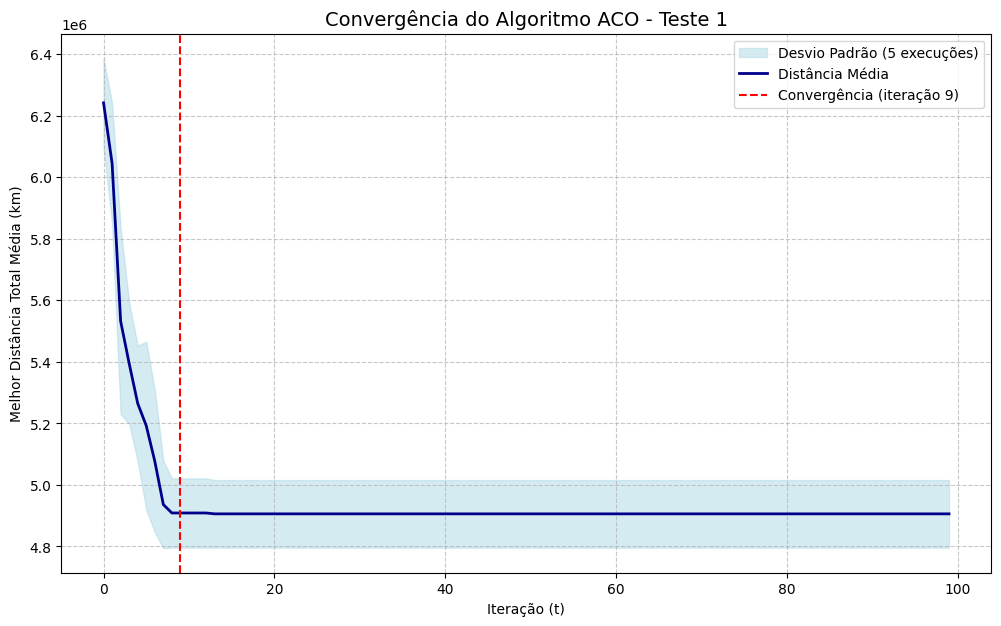

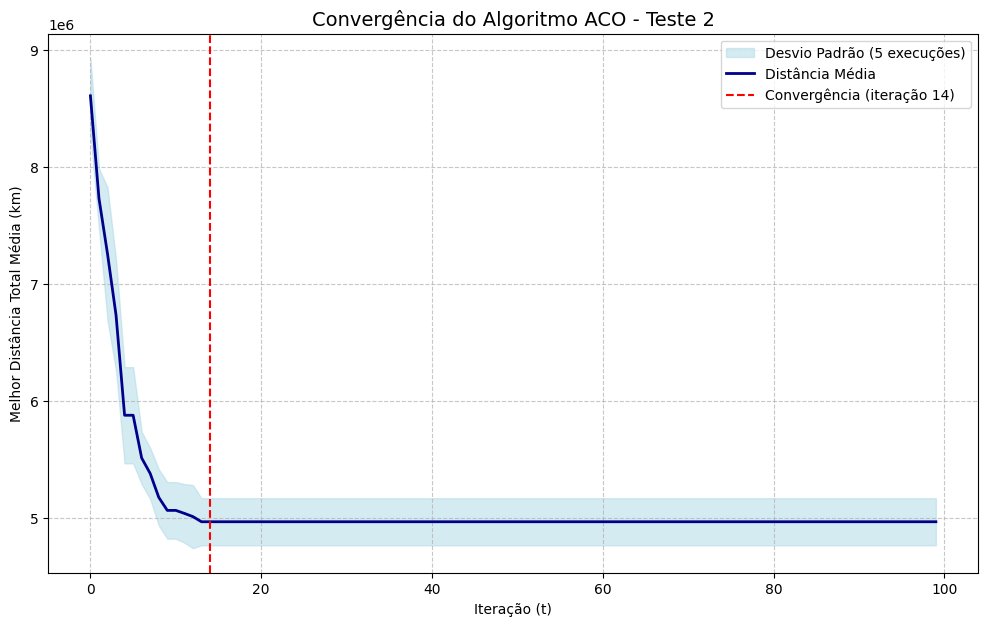

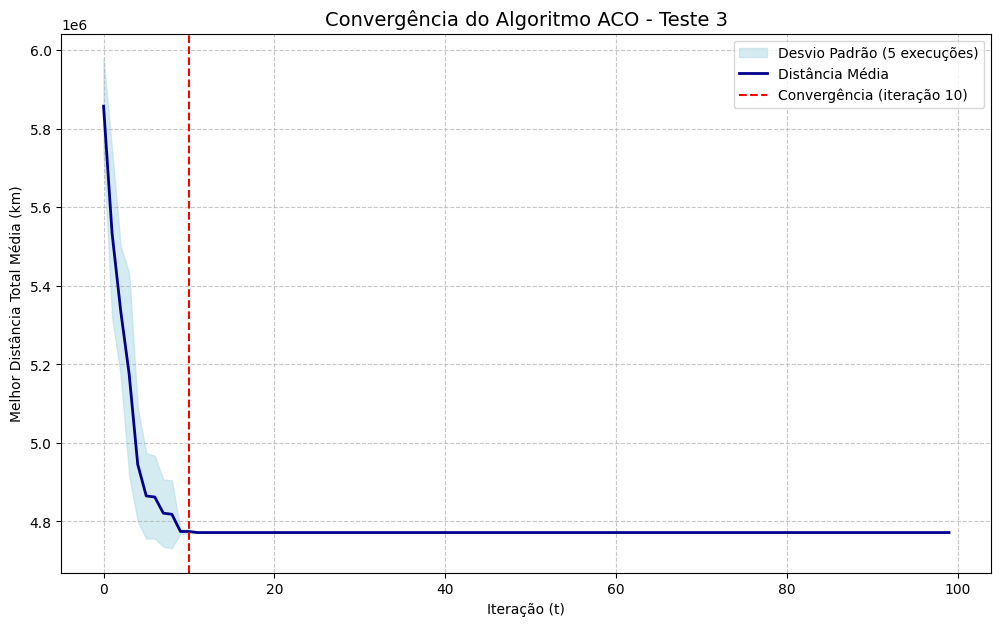

In [9]:
## CÉLULA 9: GRÁFICO DE CONVERGÊNCIA AVANÇADO

def plot_enhanced_convergence(all_conv_data, test_label):
    """
    Plota a convergência com a média das 5 execuções e a sombra do desvio padrão.
    """

    # Converte a lista de listas (5 execuções x N iterações) para um array NumPy
    conv_array = np.array(all_conv_data)

    # Calcula a média e o desvio padrão de cada coluna
    conv_array = np.array(all_conv_data)
    mean_convergence = np.mean(conv_array, axis=0)
    std_convergence = np.std(conv_array, axis=0)

    # --- NOVO CRITÉRIO VISUAL DE ESTABILIZAÇÃO ---
    convergence_point = len(mean_convergence)
    window_size = 5  # Reduzimos a janela novamente para 5 iterações
    threshold = 0.15 # Aumentamos o limiar para 0.15% (taxa mínima de melhoria)

    for i in range(len(mean_convergence) - window_size):
        start_val = mean_convergence[i]
        end_val = mean_convergence[i + window_size - 1]

        # Se a variação percentual na janela de 5 iterações for menor que 0.15%,
        # consideramos que o plateau começou, pois a melhoria é muito lenta.
        if (abs(end_val - start_val) / start_val) * 100 < threshold:
            convergence_point = i + 1 # Marcamos o início da janela de estabilidade
            break

    # PLOTAGEM
    plt.figure(figsize=(12, 7))

    # Sombra do Desvio Padrão (SD)
    plt.fill_between(range(len(mean_convergence)),
                     mean_convergence - std_convergence,
                     mean_convergence + std_convergence,
                     color='lightblue', alpha=0.5, label='Desvio Padrão (5 execuções)')

    # Linha da Média
    plt.plot(mean_convergence, color='darkblue', linewidth=2, label='Distância Média')

    # Linha Vertical Marcando a Convergência
    plt.axvline(x=convergence_point, color='red', linestyle='--',
                label=f'Convergência (iteração {convergence_point})')

    plt.title(f'Convergência do Algoritmo ACO - {test_label}', fontsize=14)
    plt.xlabel('Iteração (t)')
    plt.ylabel('Melhor Distância Total Média (km)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Chamada de exemplo (você executará esta célula depois de rodar o Teste 3):
plot_enhanced_convergence(all_convergence_data_t1, 'Teste 1')
print('')
plot_enhanced_convergence(all_convergence_data_t2, 'Teste 2')
print('')
plot_enhanced_convergence(all_convergence_data_t3, 'Teste 3')

In [10]:
## CÉLULA 10: MAPA INTERATIVO COM FOLIUM

import folium

def plot_folium_route(route_gdf, distance, test_label):
    """Cria um mapa interativo Folium para visualizar a rota."""

    # Obtém o ponto central da rota (para centralizar o mapa)
    center_lat = route_gdf['lat'].mean()
    center_lon = route_gdf['lon'].mean()

    m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles="cartodbpositron")

    # 1. Adicionar os pontos (Marcadores)
    for idx, row in route_gdf.iterrows():
        lat, lon = row['lat'], row['lon']
        label = row['identificador']

        if label == 'BELÉM (DEPOT)':
            # Marcador de Belém (Depot)
            folium.Marker(
                [lat, lon],
                tooltip=f"DEPOT: {label}",
                icon=folium.Icon(color='green', icon='fa-star', prefix='fa')
            ).add_to(m)
        else:
            # Marcadores dos Pontos de Vistoria
            folium.CircleMarker(
                [lat, lon],
                radius=5,
                color='blue',
                fill=True,
                fill_color='blue',
                fill_opacity=1,
                tooltip=f"Ponto: {label}"
            ).add_to(m)

    # 2. Adicionar a Linha da Rota
    route_coords = route_gdf[['lat', 'lon']].values.tolist()
    folium.PolyLine(route_coords, color="red", weight=3.5, opacity=0.8,
                    tooltip=f"{test_label} - Distância: {distance:.2f} km").add_to(m)

    # 3. Adicionar Título (como um elemento HTML simples)
    title_html = f'''
             <h3 align="center" style="font-size:16px"><b>{test_label} - Melhor Rota ACO ({distance:.2f} km)</b></h3>
             '''
    m.get_root().html.add_child(folium.Element(title_html))

    return m

def create_ordered_route_dataframe(route_labels, df_coordinates):
    """Cria um DataFrame ordenado com as coordenadas da rota e o ponto inicial/final (Belém)."""
    # Adiciona Belém como ponto inicial e final
    belem_coords = pd.DataFrame([{'identificador': 'BELÉM (DEPOT)', 'lat': BELEM_LAT, 'lon': BELEM_LON}])

    # Filtra as coordenadas dos nós da rota na ordem correta
    route_coords = df_coordinates[df_coordinates['identificador'].isin(route_labels)].set_index('identificador')
    ordered_route_coords = route_coords.loc[route_labels].reset_index()

    # Concatena Belém, a rota e Belém novamente
    final_route_gdf = pd.concat([belem_coords, ordered_route_coords, belem_coords], ignore_index=True)

    return final_route_gdf

# Exemplo de chamada:
#route_gdf_t1 = create_ordered_route_dataframe(best_route_t1, df_coords.copy())
#melhor_dist_t1 = np.min(all_distances_t1)
#plot_folium_route(route_gdf_t1, melhor_dist_t1, 'Teste 1 - Baseline')

#route_gdf_t2 = create_ordered_route_dataframe(best_route_t2, df_coords.copy())
#melhor_dist_t2 = np.min(all_distances_t2)
#plot_folium_route(route_gdf_t2, melhor_dist_t2, 'Teste 2 - Baseline')

#route_gdf_t3 = create_ordered_route_dataframe(best_route_t3, df_coords.copy())
#melhor_dist_t3 = np.min(all_distances_t3)
#plot_folium_route(route_gdf_t3, melhor_dist_t3, 'Teste 3 - Baseline')

### Análise Comparativa e Melhor Resultado

In [11]:
## CÉLULA 11: ANÁLISE COMPARATIVA FINAL

# Construa o DataFrame de Resultados Finais
results_df = pd.DataFrame({
    'Teste': ['Teste 1 (Baseline)', 'Teste 2 (Alpha > Beta)', 'Teste 3 (Alpha Alto & Pop.)'],
    'Alpha': [TESTE_1['alpha'], TESTE_2['alpha'], TESTE_3['alpha']],
    'Beta': [TESTE_1['beta'], TESTE_2['beta'], TESTE_3['beta']],
    'Ants (m)': [TESTE_1['num_ants'], TESTE_2['num_ants'], TESTE_3['num_ants']],

    # MÉTRICAS DE DESEMPENHO (Performance Metrics)
    'Melhor Distância (km)': [np.min(all_distances_t1), np.min(all_distances_t2), np.min(all_distances_t3)],
    'Média Distância (km)': [np.mean(all_distances_t1), np.mean(all_distances_t2), np.mean(all_distances_t3)],
    'DP Distância': [np.std(all_distances_t1), np.std(all_distances_t2), np.std(all_distances_t3)],
    'Tempo Médio (s)': [np.mean(all_times_t1), np.mean(all_times_t2), np.mean(all_times_t3)],
})

print("Tabela de Comparação Estatística entre os 3 Testes:")
display(results_df.round(2))

# GERE OS MAPAS FINAIS DOS 3 TESTES PARA COMPARAÇÃO VISUAL:
route_gdf_t1 = create_ordered_route_dataframe(best_route_t1, df_coords.copy())
plot_folium_route(route_gdf_t1, np.min(all_distances_t1), 'Teste 1 - Baseline')

route_gdf_t2 = create_ordered_route_dataframe(best_route_t2, df_coords.copy())
plot_folium_route(route_gdf_t2, np.min(all_distances_t2), 'Teste 2 - Baseline')

route_gdf_t3 = create_ordered_route_dataframe(best_route_t3, df_coords.copy())
plot_folium_route(route_gdf_t3, np.min(all_distances_t3), 'Teste 3 - Baseline')

Tabela de Comparação Estatística entre os 3 Testes:


,Teste,Alpha,Beta,Ants (m),Melhor Distância (km),Média Distância (km),DP Distância,Tempo Médio (s)
0,Teste 1 (Baseline),1.5,1.7,30,4771702.16,4906012.06,109776.98,7.95
1,Teste 2 (Alpha > Beta),1.7,0.5,30,4771702.16,4971155.47,200978.80,7.99
2,Teste 3 (Alpha Alto & Pop.),1.0,2.5,50,4771702.16,4771702.16,0.00,12.83
